## Imports

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


## load the image

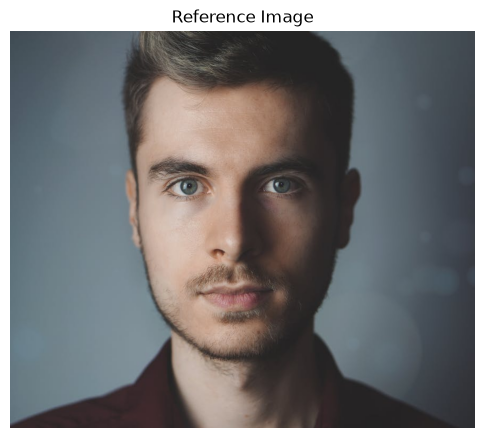

Image size (height, width, channels): (750, 878, 3)


In [3]:


IMAGE_PATH = "data/face1.jpeg"

# Load the image (OpenCV reads it in BGR order)
bgr_image = cv2.imread(IMAGE_PATH)

# BGR -> RGB (so colors look correct in matplotlib)
reference_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

# RGB -> grayscale (what ORB will analyze)
reference_gray = cv2.cvtColor(reference_image, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6, 6))
plt.title("Reference Image")
plt.imshow(reference_image)
plt.axis("off")
plt.show()

print("Image size (height, width, channels):", reference_image.shape)

## Create a Transformed Image (the "Query")

To test whether ORB can recognize the same object under change, we build a query image: smaller and rotated.

* `cv2.pyrDown` shrinks the image by half. We do it twice -> about 1/4 of the original size (scale change).
* `cv2.getRotationMatrix2D` + `cv2.warpAffine` rotate it (rotation).

This simulates seeing the same scene from a different distance and angle.

Same object -> different scale and orientation. Will the features survive?

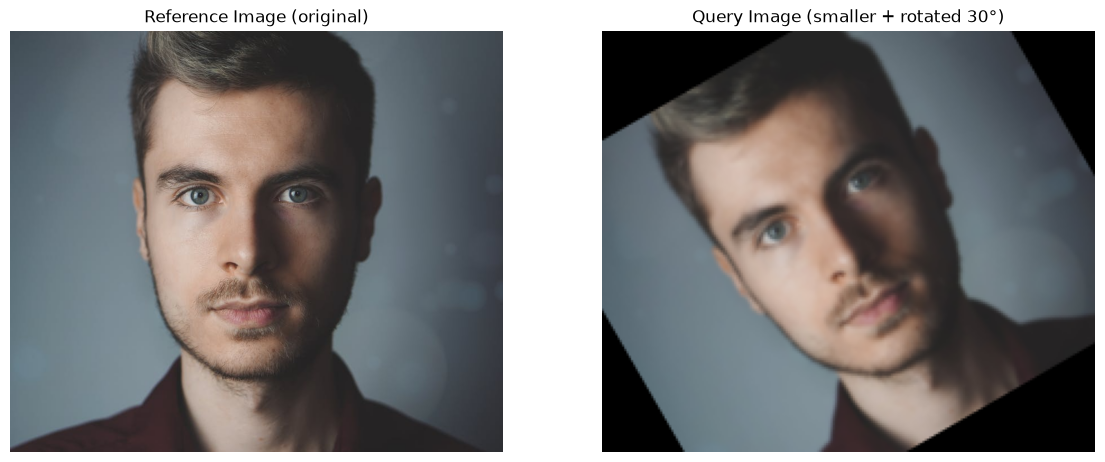

In [5]:
# 1) Make it smaller (scale change)
query_image = cv2.pyrDown(reference_image)
query_image = cv2.pyrDown(query_image)

# 2) Rotate it (orientation change)
rows, cols = query_image.shape[:2]
angle = 30 # degrees
rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1)
query_image = cv2.warpAffine(query_image, rotation_matrix, (cols, rows))

# Grayscale copy for ORB
query_gray = cv2.cvtColor(query_image, cv2.COLOR_RGB2GRAY)

# Show reference vs query side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].set_title("Reference Image (original)")
axes[0].imshow(reference_image)
axes[0].axis("off")

axes[1].set_title(f"Query Image (smaller + rotated {angle}°)")
axes[1].imshow(query_image)
axes[1].axis("off")
plt.show()


Observe: The query image is clearly smaller and tilted, but it is still the same picture. A human recognizes it instantly. Now let's see if ORB can too.


## Detect ORB Keypoints


ORB is a feature detector and descriptor. It finds distinctive points in an image (like corners and textured spots) and then describes what each one looks like.

A keypoint is a location the algorithm found interesting.

detectAndCompute does two jobs at once:
* detect the keypoints (the where), and
* compute the descriptors (the what — we'll use those in the matching step).

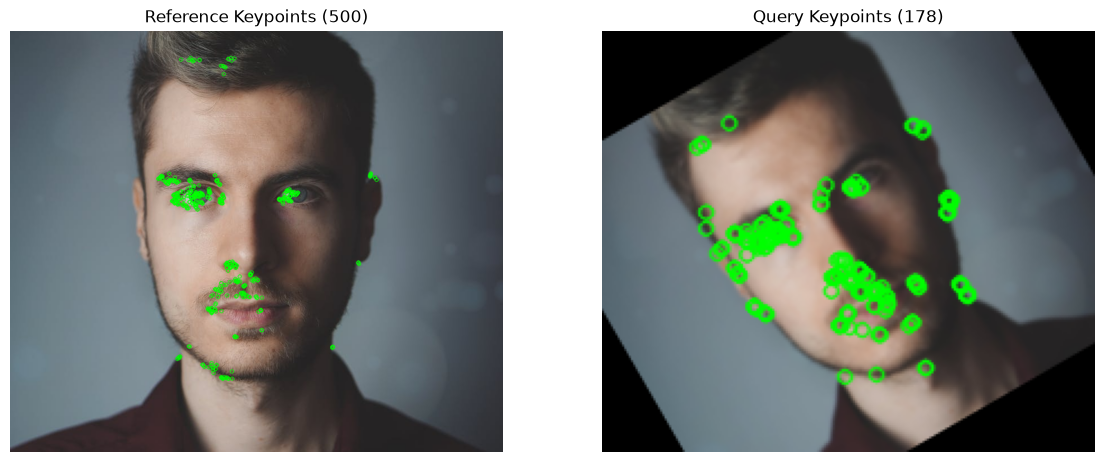

Keypoints in reference image: 500
Keypoints in query image:    178


In [6]:
# Create the ORB detector
orb = cv2.ORB_create()

# Detect keypoints AND compute descriptors for both images
reference_keypoints, reference_descriptors = orb.detectAndCompute(reference_gray, None)
query_keypoints, query_descriptors = orb.detectAndCompute(query_gray, None)

# Draw the keypoints on each image
reference_with_kp = cv2.drawKeypoints(reference_image, reference_keypoints, None, color=(0, 255, 0))
query_with_kp = cv2.drawKeypoints(query_image, query_keypoints, None, color=(0, 255, 0))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].set_title(f"Reference Keypoints ({len(reference_keypoints)})")
axes[0].imshow(reference_with_kp)
axes[0].axis("off")

axes[1].set_title(f"Query Keypoints ({len(query_keypoints)})")
axes[1].imshow(query_with_kp)
axes[1].axis("off")
plt.show()

print("Keypoints in reference image:", len(reference_keypoints))
print("Keypoints in query image:   ", len(query_keypoints))


Observe: Each green dot is one keypoint — a spot ORB thinks is distinctive. The smaller query has fewer because there is less detail after shrinking it.

## Bonus: keypoints carry size and orientation

A keypoint is more than a dot. It also has a scale (how big the feature is) and an orientation (which way it points). Drawing with `DRAW_RICH_KEYPOINTS` shows this as circles with a line.

That orientation is exactly what lets ORB stay reliable when the image is rotated.



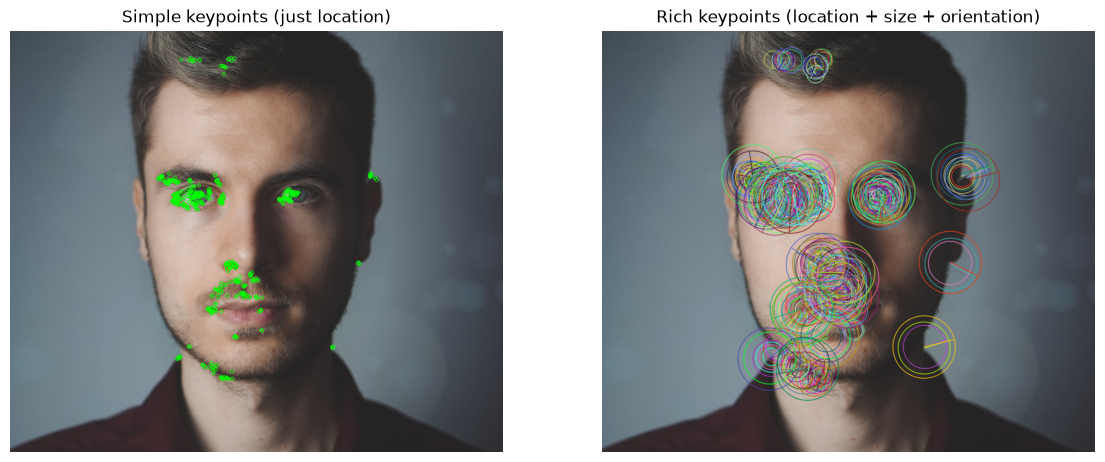

In [7]:
plain = cv2.drawKeypoints(reference_image, reference_keypoints, None, color=(0, 255, 0))
rich = cv2.drawKeypoints(reference_image, reference_keypoints, None,
                         flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].set_title("Simple keypoints (just location)")
axes[0].imshow(plain)
axes[0].axis("off")

axes[1].set_title("Rich keypoints (location + size + orientation)")
axes[1].imshow(rich)
axes[1].axis("off")
plt.show()


Observe: Bigger circles = features detected at a larger scale. The little line inside each circle is the feature's orientation. This "size + orientation" information is what makes ORB robust to scaling and rotation.


## Keypoints vs Descriptors — What's the Difference

This is the most important idea in the whole lab, so let's say it plainly:

| Term | Question it answers | Think of it as... |
| :--- | :--- | :--- |
| **Keypoint** | WHERE is the interesting feature? | a pin on a map |
| **Descriptor** | WHAT does that feature look like? | fingerprint the computer can compare |

We can see keypoints as dots. Descriptors are a compact, machine-comparable summary of the small patch of pixels around each keypoint. The computer never compares keypoints directly; it compares descriptors.

In [8]:
print("reference_descriptors.shape:", reference_descriptors.shape)
print("query_descriptors.shape:   ", query_descriptors.shape)


reference_descriptors.shape: (500, 32)
query_descriptors.shape:    (178, 32)



Observe: The shape is (number_of_keypoints, 32).

* The first number = how many keypoints were described (one descriptor per keypoint).


* The 32 = each descriptor is 32 numbers long. (ORB descriptors are binary, which matters for the next step.)



So a descriptor is simply a fixed-length fingerprint for each keypoint. That's all we need to know — we don't need the internal math to use them.

## Match the Descriptors

Now the payoff. We have a fingerprint (descriptor) for every keypoint in both images. To find correspondence, we look for the descriptor in the reference, which descriptor in the query is the most similar?

* We use a Brute-Force Matcher (`cv2.BFMatcher`); it compares every descriptor against every other descriptor.
* Because ORB descriptors are binary, we measure similarity with Hamming distance (`cv2.NORM_HAMMING`). Smaller distance = fewer bits differ.
* `crossCheck=True` keeps only pairs that agree both ways (A's best match is B, and B's best match is A).

Smaller Hamming distance = more similar descriptors = a better match.

In [9]:
# Brute-Force matcher using Hamming distance (correct choice for binary ORB descriptors)
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Match reference descriptors against query descriptors
matches = matcher.match(reference_descriptors, query_descriptors)

# Sort matches so the best (smallest distance) come first
matches = sorted(matches, key=lambda m: m.distance)

print("Total matches found:", len(matches))
print("Best match distance: ", matches[0].distance, "(smaller = more similar)")
print("Worst match distance:", matches[-1].distance)


Total matches found: 84
Best match distance:  14.0 (smaller = more similar)
Worst match distance: 79.0


Observe: Each entry in matches links one keypoint in the reference to one keypoint in the query. Because we sorted by distance, matches[0] is the single most confident correspondence.


## Visualize the Best Matches

`cv2.drawMatches` draws both images side by side and connects matched keypoints with lines. Even though the query is scaled and rotated, the picture stays readable.

Each line connects a feature in the reference image to a similar feature in the transformed (query) image.

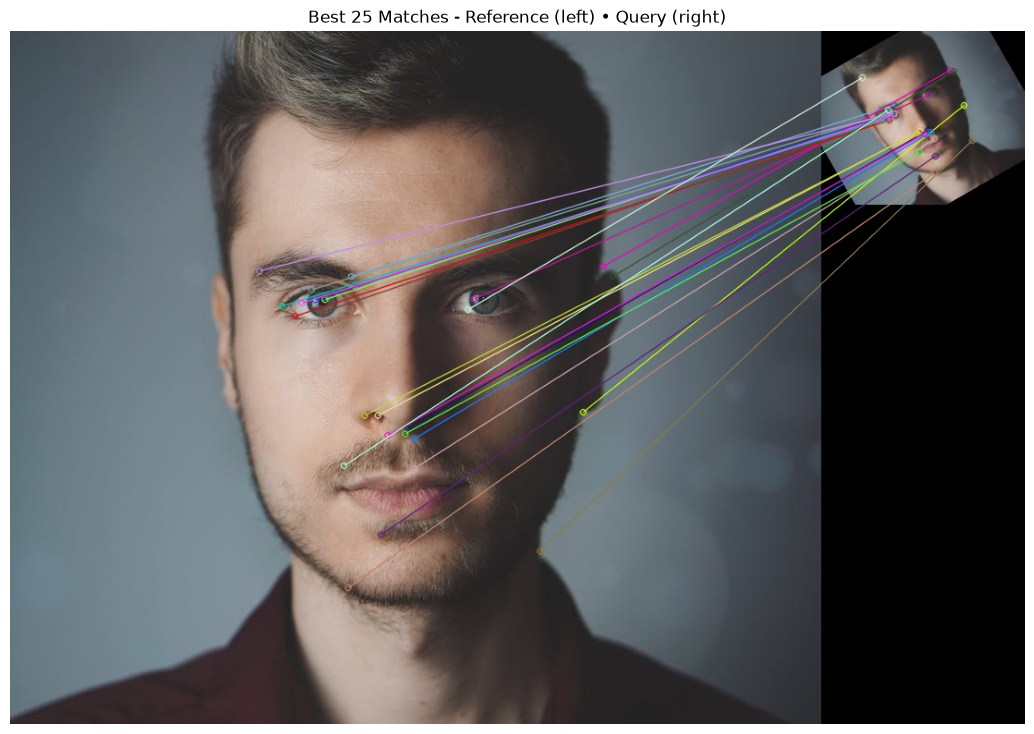

In [10]:
num_matches_to_show = 25

matched_image = cv2.drawMatches(
    reference_image, reference_keypoints,
    query_image, query_keypoints,
    matches[:num_matches_to_show], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

plt.figure(figsize=(18, 9))
plt.title(f"Best {num_matches_to_show} Matches - Reference (left) • Query (right)")
plt.imshow(matched_image)
plt.axis("off")
plt.show()


A few lines may look "wrong" — no matcher is perfect. Notice how the good matches tend to have the smaller distances (that's why we sorted).


## Experiment: How Robust Is ORB?

Let's turn the whole pipeline into one function so you can experiment easily. Change the inputs and re-run to see how ORB handles transformations.[cite: 17]

By these
* Rotation angle: 0, 30, 60, 90
* Scale (shrink steps): 0 (same size), 1 (half), 2 (quarter)
* Number of matches shown: 10, 25, 50

For each experiment, watch:
1. How many keypoints are detected in the query?
2. How many matches are found, and do the lines still connect the same features?
3. At what point does ORB start to struggle?

angle=30°, shrink_steps=2
  query keypoints: 178
  matches found:   84


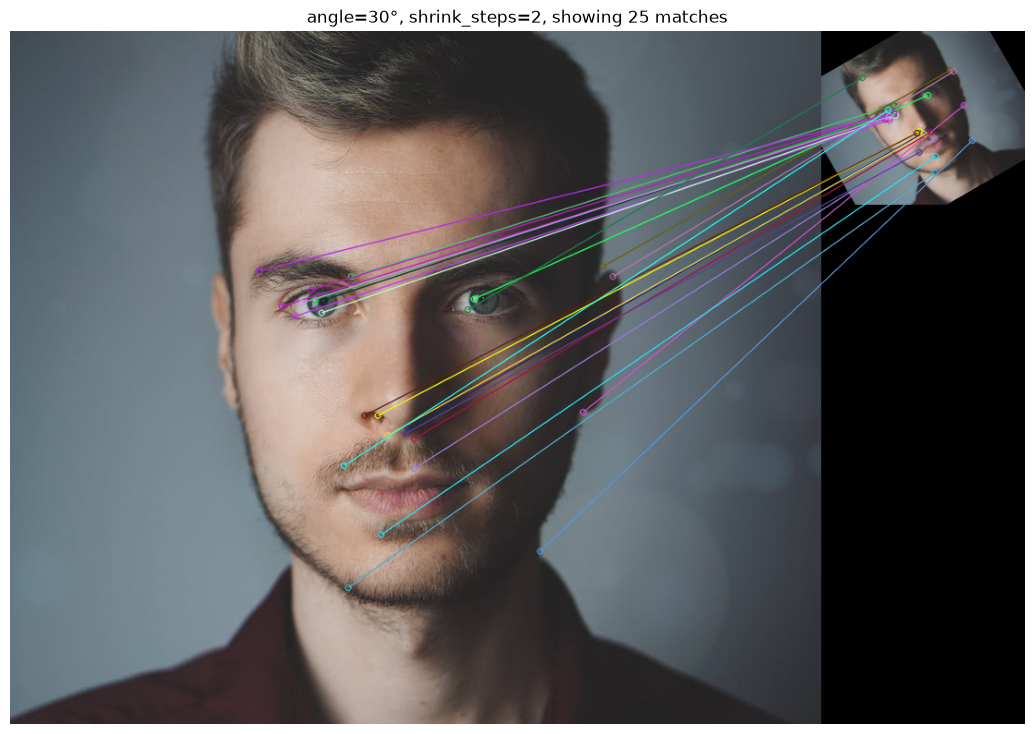

In [11]:
def run_orb_experiment(angle=30, shrink_steps=2, num_matches_to_show=25):
    """Build a query image, run the ORB pipeline, and show the matches."""
    # 1) Build the query image (scale + rotation)
    q_img = reference_image.copy()
    for _ in range(shrink_steps):
        q_img = cv2.pyrDown(q_img)
    rows, cols = q_img.shape[:2]
    M = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1)
    q_img = cv2.warpAffine(q_img, M, (cols, rows))
    q_gray = cv2.cvtColor(q_img, cv2.COLOR_RGB2GRAY)

    # 2) Detect + describe
    ref_kp, ref_desc = orb.detectAndCompute(reference_gray, None)
    q_kp, q_desc = orb.detectAndCompute(q_gray, None)

    # 3) Match
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    ms = sorted(bf.match(ref_desc, q_desc), key=lambda m: m.distance)

    # 4) Report + visualize
    print(f"angle={angle}°, shrink_steps={shrink_steps}")
    print(f"  query keypoints: {len(q_kp)}")
    print(f"  matches found:   {len(ms)}")

    out = cv2.drawMatches(reference_image, ref_kp, q_img, q_kp,
                          ms[:num_matches_to_show], None,
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    plt.figure(figsize=(18, 9))
    plt.title(f"angle={angle}°, shrink_steps={shrink_steps}, showing {num_matches_to_show} matches")
    plt.imshow(out)
    plt.axis("off")
    plt.show()

#  Change these numbers and re-run the cell!
run_orb_experiment(angle=30, shrink_steps=2, num_matches_to_show=25)
